In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, f1_score

import optuna
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import warnings


pd.set_option('display.max_columns', None)

/Users/sahirskd/Desktop/Projects/Learning/Candidate_Take-Home_Assignment/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading Data

In [2]:
df_distributors = pd.read_csv("../data/assignment_distributors.csv")
df_orders = pd.read_csv("../data/assignment_orders.csv")
df_payments = pd.read_csv("../data/assignment_payments.csv")

In [3]:
df_distributors

,distributor_id,distributor_name,region,city,channel,credit_limit_inr,credit_terms_days,onboarded_date
0,DIST-001,Om Brothers,North,Delhi,institution,300000,21,2022-04-03
1,DIST-002,Modern Traders,North,Chandigarh,institution,750000,15,2024-04-24
2,DIST-003,Jai Brothers,North,Delhi,modern_trade,200000,15,2024-02-24
3,DIST-004,Om Brothers,West,Mumbai,general_trade,750000,30,2021-01-14
4,DIST-005,New Traders,West,Pune,general_trade,200000,21,2025-04-13
...,...,...,...,...,...,...,...,...
115,DIST-116,Sri Suppliers,South,Bengaluru,institution,750000,21,2023-05-21
116,DIST-117,Ravi Enterprises,South,Hyderabad,modern_trade,300000,21,2021-05-27
117,DIST-118,Sri Agencies,East,Patna,institution,750000,30,2023-06-19
118,DIST-119,Sri Suppliers,East,Patna,general_trade,300000,45,2023-06-16


In [4]:
df_orders

,order_id,distributor_id,order_date,order_value_inr,order_status
0,ORD-00001,DIST-001,2026-01-11,25000.0,delivered
1,ORD-00002,DIST-001,2026-04-20,150000.0,cancelled
2,ORD-00003,DIST-001,2024-07-12,50000.0,delivered
3,ORD-00004,DIST-001,2025-09-25,100000.0,delivered
4,ORD-00005,DIST-001,2025-03-12,150000.0,delivered
...,...,...,...,...,...
1814,ORD-01815,DIST-118,2026-05-30,200000.0,delivered
1815,ORD-01816,DIST-118,2024-10-05,200000.0,delivered
1816,ORD-01817,DIST-118,2025-09-04,25000.0,delivered
1817,ORD-01818,DIST-118,2025-11-19,200000.0,delivered


In [5]:
df_payments

,payment_id,distributor_id,invoice_id,invoice_date,invoice_amount_inr,due_date,payment_date,amount_paid_inr,payment_status
0,PAY-000717,DIST-063,INV-000717,2025-09-29,257488,2025-10-29,2025-11-18,257488,paid
1,PAY-000757,DIST-067,INV-000757,2024-08-01,333376,2024-08-22,2024-10-01,333376,paid
2,PAY-000523,DIST-046,INV-000523,2025-07-02,47886,2025-07-17,2025-07-16,47886,paid
3,PAY-001173,DIST-105,INV-001173,2025-02-17,32931,2025-03-04,NaN,0,overdue
4,PAY-000678,DIST-060,INV-000678,2026-03-22,104443,2026-05-06,2026-06-03,104443,paid
...,...,...,...,...,...,...,...,...,...
1266,PAY-000146,DIST-013,INV-000146,2025-01-20,181528,2025-02-19,2025-02-17,181528,paid
1267,PAY-000183,DIST-016,INV-000183,2025-08-22,25262,2025-09-12,2025-09-10,25262,paid
1268,PAY-000724,DIST-064,INV-000724,2025-09-22,250653,2025-10-13,2025-10-11,250653,paid
1269,PAY-000745,DIST-066,INV-000745,2024-12-13,98742,2025-01-12,2025-01-10,98742,paid


In [6]:
validate_dates = {
    'payments_date': pd.to_datetime(df_payments['payment_date']),
    'order_date': pd.to_datetime(df_orders['order_date']),
    'distributor_date': pd.to_datetime(df_distributors['onboarded_date']),
}

for category in validate_dates:
    print(category)
    print("Earliest date:", validate_dates[category].min())
    print("Latest date:", validate_dates[category].max())
    print(validate_dates[category].isnull().sum())

payments_date
Earliest date: 2024-02-01 00:00:00
Latest date: 2026-07-19 00:00:00
120
order_date
Earliest date: 2024-06-01 00:00:00
Latest date: 2026-06-09 00:00:00
0
distributor_date
Earliest date: 2021-01-14 00:00:00
Latest date: 2025-05-22 00:00:00
0


In [7]:
df_payments.isnull().sum()

payment_id              0
distributor_id          0
invoice_id              0
invoice_date            0
invoice_amount_inr      0
due_date                0
payment_date          120
amount_paid_inr         0
payment_status          0
dtype: int64

In [8]:
df_payments[df_payments["payment_date"].isnull()]

,payment_id,distributor_id,invoice_id,invoice_date,invoice_amount_inr,due_date,payment_date,amount_paid_inr,payment_status
3,PAY-001173,DIST-105,INV-001173,2025-02-17,32931,2025-03-04,NaN,0,overdue
14,PAY-001045,DIST-094,INV-001045,2024-12-17,281489,2025-01-16,NaN,0,overdue
52,PAY-001105,DIST-099,INV-001105,2024-08-21,26821,2024-10-05,NaN,0,overdue
55,PAY-001035,DIST-093,INV-001035,2025-04-17,236985,2025-06-01,NaN,0,overdue
57,PAY-001027,DIST-092,INV-001027,2025-05-02,178981,2025-06-01,NaN,0,overdue
...,...,...,...,...,...,...,...,...,...
1229,PAY-001168,DIST-105,INV-001168,2024-09-03,30270,2024-09-18,NaN,0,overdue
1241,PAY-000922,DIST-082,INV-000922,2025-06-04,114893,2025-06-19,NaN,0,overdue
1242,PAY-001037,DIST-093,INV-001037,2025-06-17,289428,2025-08-01,NaN,0,overdue
1262,PAY-000970,DIST-087,INV-000970,2025-08-09,39883,2025-08-30,NaN,0,overdue


Missing dates are for due holders, so no imputation needed

In [9]:
df_distributors.nunique()

distributor_id       120
distributor_name      53
region                 4
city                  12
channel                3
credit_limit_inr       7
credit_terms_days      4
onboarded_date       118
dtype: int64

In [10]:
display(df_distributors.isna().sum())
display(df_distributors.isnull().sum())

distributor_id       0
distributor_name     0
region               0
city                 0
channel              0
credit_limit_inr     0
credit_terms_days    0
onboarded_date       0
dtype: int64

distributor_id       0
distributor_name     0
region               0
city                 0
channel              0
credit_limit_inr     0
credit_terms_days    0
onboarded_date       0
dtype: int64

In [11]:
df_orders.nunique()

order_id           1819
distributor_id      118
order_date          665
order_value_inr       7
order_status          3
dtype: int64

In [12]:
df_payments.nunique()

payment_id            1271
distributor_id         123
invoice_id            1271
invoice_date           556
invoice_amount_inr    1264
due_date               573
payment_date           530
amount_paid_inr       1123
payment_status           4
dtype: int64

In [13]:
onboarded_distributors = set(df_distributors["distributor_id"])
order_distributor_ids = set(df_orders["distributor_id"])
payment_distributor_ids = set(df_payments["distributor_id"])

In [14]:
orphaned_payments = payment_distributor_ids - onboarded_distributors
orphaned_orders = order_distributor_ids - onboarded_distributors
no_order_distributors = onboarded_distributors - order_distributor_ids

print(f"orphaned_payments distributors: {orphaned_payments}")
print(f"orphaned_orders: {orphaned_orders}")
print(f"no_order_distributors: {no_order_distributors}")

orphaned_payments distributors: {'DIST-901', 'DIST-903', 'DIST-902', 'DIST-900', 'DIST-904'}
orphaned_orders: set()
no_order_distributors: {'DIST-119', 'DIST-120'}


In [15]:
df_payments

,payment_id,distributor_id,invoice_id,invoice_date,invoice_amount_inr,due_date,payment_date,amount_paid_inr,payment_status
0,PAY-000717,DIST-063,INV-000717,2025-09-29,257488,2025-10-29,2025-11-18,257488,paid
1,PAY-000757,DIST-067,INV-000757,2024-08-01,333376,2024-08-22,2024-10-01,333376,paid
2,PAY-000523,DIST-046,INV-000523,2025-07-02,47886,2025-07-17,2025-07-16,47886,paid
3,PAY-001173,DIST-105,INV-001173,2025-02-17,32931,2025-03-04,NaN,0,overdue
4,PAY-000678,DIST-060,INV-000678,2026-03-22,104443,2026-05-06,2026-06-03,104443,paid
...,...,...,...,...,...,...,...,...,...
1266,PAY-000146,DIST-013,INV-000146,2025-01-20,181528,2025-02-19,2025-02-17,181528,paid
1267,PAY-000183,DIST-016,INV-000183,2025-08-22,25262,2025-09-12,2025-09-10,25262,paid
1268,PAY-000724,DIST-064,INV-000724,2025-09-22,250653,2025-10-13,2025-10-11,250653,paid
1269,PAY-000745,DIST-066,INV-000745,2024-12-13,98742,2025-01-12,2025-01-10,98742,paid


### Adding columns usefull to define the high risk criteria

In [16]:
df_payments["invoice_date"] = pd.to_datetime(df_payments["invoice_date"])
df_payments["due_date"] = pd.to_datetime(df_payments["due_date"])
df_payments["payment_date"] = pd.to_datetime(df_payments["payment_date"])

In [17]:
df_payments["unpaid_amount"] = df_payments["invoice_amount_inr"] - df_payments["amount_paid_inr"].fillna(0)

In [18]:
snapshot_date = df_payments[["due_date", "payment_date"]].max()
snapshot_date

due_date       2026-07-21
payment_date   2026-07-19
dtype: datetime64[us]

In [19]:
snapshot_date = snapshot_date.max()
snapshot_date

Timestamp('2026-07-21 00:00:00')

In [20]:
df_payments["delay_days"] = (df_payments["payment_date"].fillna(snapshot_date) - df_payments["due_date"]).dt.days

Counting delays till the maximum date available in payment or due date

In [21]:
# df_payments[df_payments["payment_date"].isnull()]

In [22]:
df_payments.loc[df_payments["amount_paid_inr"] < df_payments["invoice_amount_inr"]]

,payment_id,distributor_id,invoice_id,invoice_date,invoice_amount_inr,due_date,payment_date,amount_paid_inr,payment_status,unpaid_amount,delay_days
3,PAY-001173,DIST-105,INV-001173,2025-02-17,32931,2025-03-04,NaT,0,overdue,32931,504
7,PAY-001216,DIST-111,INV-001216,2024-09-02,145941,2024-10-17,2024-11-06,78960,partial,66981,20
8,PAY-001183,DIST-106,INV-001183,2024-12-30,252310,2025-01-29,2025-02-09,126896,partial,125414,11
14,PAY-001045,DIST-094,INV-001045,2024-12-17,281489,2025-01-16,NaT,0,overdue,281489,551
22,PAY-000928,DIST-083,INV-000928,2025-06-30,71916,2025-07-21,2025-08-05,50678,partial,21238,15
...,...,...,...,...,...,...,...,...,...,...,...
1241,PAY-000922,DIST-082,INV-000922,2025-06-04,114893,2025-06-19,NaT,0,overdue,114893,397
1242,PAY-001037,DIST-093,INV-001037,2025-06-17,289428,2025-08-01,NaT,0,overdue,289428,354
1262,PAY-000970,DIST-087,INV-000970,2025-08-09,39883,2025-08-30,NaT,0,overdue,39883,325
1264,PAY-000944,DIST-084,INV-000944,2025-09-03,51489,2025-10-18,NaT,0,overdue,51489,276


In [23]:
df_payments.loc[df_payments["amount_paid_inr"] > df_payments["invoice_amount_inr"]]

,payment_id,distributor_id,invoice_id,invoice_date,invoice_amount_inr,due_date,payment_date,amount_paid_inr,payment_status,unpaid_amount,delay_days
113,PAY-000154,DIST-014,INV-000154,2025-03-06,56690,2025-03-27,2025-03-24,75214,paid,-18524,-3
522,PAY-000313,DIST-028,INV-000313,2025-12-26,27116,2026-01-16,2026-01-14,40613,paid,-13497,-2


In [24]:
df_payments.loc[df_payments["amount_paid_inr"] > df_payments["invoice_amount_inr"], "amount_paid_inr"] = df_payments["invoice_amount_inr"]

In [25]:
df_payments

,payment_id,distributor_id,invoice_id,invoice_date,invoice_amount_inr,due_date,payment_date,amount_paid_inr,payment_status,unpaid_amount,delay_days
0,PAY-000717,DIST-063,INV-000717,2025-09-29,257488,2025-10-29,2025-11-18,257488,paid,0,20
1,PAY-000757,DIST-067,INV-000757,2024-08-01,333376,2024-08-22,2024-10-01,333376,paid,0,40
2,PAY-000523,DIST-046,INV-000523,2025-07-02,47886,2025-07-17,2025-07-16,47886,paid,0,-1
3,PAY-001173,DIST-105,INV-001173,2025-02-17,32931,2025-03-04,NaT,0,overdue,32931,504
4,PAY-000678,DIST-060,INV-000678,2026-03-22,104443,2026-05-06,2026-06-03,104443,paid,0,28
...,...,...,...,...,...,...,...,...,...,...,...
1266,PAY-000146,DIST-013,INV-000146,2025-01-20,181528,2025-02-19,2025-02-17,181528,paid,0,-2
1267,PAY-000183,DIST-016,INV-000183,2025-08-22,25262,2025-09-12,2025-09-10,25262,paid,0,-2
1268,PAY-000724,DIST-064,INV-000724,2025-09-22,250653,2025-10-13,2025-10-11,250653,paid,0,-2
1269,PAY-000745,DIST-066,INV-000745,2024-12-13,98742,2025-01-12,2025-01-10,98742,paid,0,-2


## Defining the risk criteria

- Order ID with overdue or unpaid invoice
- Unpaid ratio is greater than 15% of invoice amount
- Average payment delays are greater than 20 days after due date

In [26]:
# Assumed thresholds
DAYS_DUE = 20
UNPAID_DUE_PERCENT = 0.15

print("Invoice date range:", df_payments["invoice_date"].min(), "->", df_payments["invoice_date"].max())

# Added the cutoff date in middle of the dataset dates, in production it will be today and so on
CUTOFF_DATE = pd.Timestamp("2025-10-01")

print("CUTOFF_DATE:", CUTOFF_DATE)

print("Invoices before CUTOFF_DATE:", (df_payments["invoice_date"] < CUTOFF_DATE).sum()) # my features window
print("Invoices on/after CUTOFF_DATE:", (df_payments["invoice_date"] >= CUTOFF_DATE).sum()) # labels window

Invoice date range: 2024-01-04 00:00:00 -> 2026-06-06 00:00:00
CUTOFF_DATE: 2025-10-01 00:00:00
Invoices before CUTOFF_DATE: 1018
Invoices on/after CUTOFF_DATE: 253


In [27]:
df_payments_hist = df_payments[df_payments["invoice_date"] < CUTOFF_DATE].copy()
df_payments_future = df_payments[df_payments["invoice_date"] >= CUTOFF_DATE].copy()

df_orders["order_date"] = pd.to_datetime(df_orders["order_date"])
df_orders_hist = df_orders[df_orders["order_date"] < CUTOFF_DATE].copy()

### Building the label from the future window only

In [28]:
def calculate_payment_criterias(group):
    total_invoiced = group["invoice_amount_inr"].sum()
    total_unpaid = group["unpaid_amount"].sum()

    return pd.Series({
        "total_invoiced": total_invoiced,
        "total_unpaid": total_unpaid,
        "unpaid_ratio": total_unpaid / (total_invoiced + 1e-6),
        "has_overdue": (group["payment_status"] == "overdue").any(),
        "avg_delay": group["delay_days"].mean(),
        "bad_debt": (group["payment_status"] == "written_off").any(),
        "n_future_invoices": len(group),
    })

payment_labels = (
    df_payments_future.groupby("distributor_id")
    .apply(calculate_payment_criterias, include_groups=False)
    .reset_index()
)

payment_labels["high_risk"] = (
    (payment_labels["has_overdue"]) |
    (payment_labels["bad_debt"]) |
    (payment_labels["unpaid_ratio"] > UNPAID_DUE_PERCENT) |
    (payment_labels["avg_delay"] > DAYS_DUE)
).astype(int)

print(payment_labels["high_risk"].value_counts(normalize=True))
payment_labels.sample(10)

high_risk
0    0.754098
1    0.245902
Name: proportion, dtype: float64


,distributor_id,total_invoiced,total_unpaid,unpaid_ratio,has_overdue,avg_delay,bad_debt,n_future_invoices,high_risk
27,DIST-048,118983,0,0.000000,False,-0.500000,False,2,0
23,DIST-043,402274,0,0.000000,False,-1.500000,False,6,0
46,DIST-083,442189,41978,0.094932,False,6.800000,False,5,0
43,DIST-079,81141,0,0.000000,False,37.000000,False,1,1
40,DIST-072,158196,0,0.000000,False,18.285714,False,7,0
37,DIST-064,855512,0,0.000000,False,29.200000,False,5,1
34,DIST-060,1004932,0,0.000000,False,8.857143,False,7,0
59,DIST-115,124244,124244,1.000000,True,240.500000,False,2,1
58,DIST-107,633805,367903,0.580467,True,87.333333,False,3,1
55,DIST-101,334587,258082,0.771345,True,142.500000,False,2,1


Class imbalance is there, will handle it with class_weight="balanced" / scale_pos_weight at modeling time or will see if labels has to be balanced via SMOTE or ADASYN

In [29]:
no_future_activity = set(df_distributors["distributor_id"]) - set(payment_labels["distributor_id"])
print(f"no_future_activity distributors: {len(no_future_activity)}")
print(no_future_activity)

no_future_activity distributors: 60
{'DIST-109', 'DIST-067', 'DIST-001', 'DIST-077', 'DIST-106', 'DIST-030', 'DIST-092', 'DIST-099', 'DIST-037', 'DIST-020', 'DIST-050', 'DIST-007', 'DIST-005', 'DIST-108', 'DIST-053', 'DIST-041', 'DIST-032', 'DIST-038', 'DIST-089', 'DIST-014', 'DIST-118', 'DIST-066', 'DIST-093', 'DIST-029', 'DIST-075', 'DIST-042', 'DIST-116', 'DIST-056', 'DIST-110', 'DIST-105', 'DIST-052', 'DIST-006', 'DIST-074', 'DIST-045', 'DIST-069', 'DIST-112', 'DIST-076', 'DIST-018', 'DIST-114', 'DIST-063', 'DIST-117', 'DIST-023', 'DIST-013', 'DIST-100', 'DIST-113', 'DIST-025', 'DIST-111', 'DIST-068', 'DIST-084', 'DIST-057', 'DIST-091', 'DIST-086', 'DIST-071', 'DIST-033', 'DIST-094', 'DIST-119', 'DIST-120', 'DIST-103', 'DIST-035', 'DIST-082'}


### Building features from the history dataset window only

#### Payment features

In [30]:
payment_feats = df_payments_hist.groupby("distributor_id").agg(
    total_invoices=("invoice_id", "count"),
    total_invoice_amt=("invoice_amount_inr", "sum"),
    total_paid_amt=("amount_paid_inr", "sum"),
    total_unpaid_amt=("unpaid_amount", "sum"),
    avg_delay_days=("delay_days", "mean"),
    max_delay_days=("delay_days", "max"),
    on_time_payment_count=("delay_days", lambda x: (x <= 0).sum()),
    overdue_count=("payment_status", lambda x: (x == "overdue").sum()),
    partial_count=("payment_status", lambda x: (x == "partial").sum())
).reset_index()

payment_feats["on_time_ratio"] = payment_feats["on_time_payment_count"] / payment_feats["total_invoices"]
payment_feats["overdue_ratio"] = payment_feats["overdue_count"] / payment_feats["total_invoices"]

payment_feats.sample(min(10, len(payment_feats)))

,distributor_id,total_invoices,total_invoice_amt,total_paid_amt,total_unpaid_amt,avg_delay_days,max_delay_days,on_time_payment_count,overdue_count,partial_count,on_time_ratio,overdue_ratio
8,DIST-009,8,985994,985994,0,-1.500000,0,8,0,0,1.00,0.000000
89,DIST-090,10,457933,275212,182721,126.300000,496,2,3,2,0.20,0.300000
116,DIST-117,7,388915,0,388915,162.857143,575,0,1,0,0.00,0.142857
66,DIST-067,12,2953652,2953652,0,21.916667,44,3,0,0,0.25,0.000000
19,DIST-020,13,2053069,2053069,0,-1.461538,0,13,0,0,1.00,0.000000
103,DIST-104,8,1411946,728551,683395,117.125000,450,0,2,4,0.00,0.250000
38,DIST-039,9,1595413,1595413,0,-1.000000,0,9,0,0,1.00,0.000000
31,DIST-032,10,2661963,2661963,0,-1.500000,0,10,0,0,1.00,0.000000
47,DIST-048,9,403200,403200,0,-1.222222,0,9,0,0,1.00,0.000000
24,DIST-025,9,2340962,2340962,0,-2.333333,-1,9,0,0,1.00,0.000000


#### Order features

In [31]:
df_orders_hist.isna().sum()

order_id           0
distributor_id     0
order_date         0
order_value_inr    2
order_status       0
dtype: int64

In [32]:
df_orders_hist[df_orders_hist['order_value_inr'].isna()]

,order_id,distributor_id,order_date,order_value_inr,order_status
89,ORD-00090,DIST-007,2024-10-13,NaN,delivered
779,ORD-00780,DIST-050,2025-09-09,NaN,pending


In [33]:
df_orders_hist['order_value_inr'] = df_orders_hist['order_value_inr'].fillna(0)

In [34]:
df_orders_hist[df_orders_hist['order_value_inr'].isna()]

,order_id,distributor_id,order_date,order_value_inr,order_status


In [35]:
order_feats = df_orders_hist.groupby("distributor_id").agg(
    total_orders=("order_id", "count"),
    total_order_value=("order_value_inr", "sum"),
    avg_order_value=("order_value_inr", "mean"),
    cancelled_orders=("order_status", lambda x: (x == "cancelled").sum()),
    delivered_orders=("order_status", lambda x: (x == "delivered").sum()),
    latest_order_date=("order_date", "max")
).reset_index()

order_feats["cancellation_rate"] = order_feats["cancelled_orders"] / order_feats["total_orders"]

order_feats.head()

,distributor_id,total_orders,total_order_value,avg_order_value,cancelled_orders,delivered_orders,latest_order_date,cancellation_rate
0,DIST-001,16,1750000.0,109375.000000,1,12,2025-09-25,0.0625
1,DIST-002,4,625000.0,156250.000000,1,2,2025-09-11,0.2500
2,DIST-003,10,1650000.0,165000.000000,2,7,2025-09-28,0.2000
3,DIST-004,11,1600000.0,145454.545455,0,11,2025-09-24,0.0000
4,DIST-005,6,575000.0,95833.333333,0,4,2025-09-20,0.0000


In [36]:
order_feats.isna().sum()

distributor_id       0
total_orders         0
total_order_value    0
avg_order_value      0
cancelled_orders     0
delivered_orders     0
latest_order_date    0
cancellation_rate    0
dtype: int64

### Merging features to create the master dataframe

In [37]:
df_master = df_distributors.merge(payment_feats, on="distributor_id", how="left")
df_master = df_master.merge(order_feats, on="distributor_id", how="left")

# only distributors who have future activity
df_master = df_master.merge(payment_labels[["distributor_id", "high_risk"]], on="distributor_id", how="inner")

df_master.sample(10)

,distributor_id,distributor_name,region,city,channel,credit_limit_inr,credit_terms_days,onboarded_date,total_invoices,total_invoice_amt,total_paid_amt,total_unpaid_amt,avg_delay_days,max_delay_days,on_time_payment_count,overdue_count,partial_count,on_time_ratio,overdue_ratio,total_orders,total_order_value,avg_order_value,cancelled_orders,delivered_orders,latest_order_date,cancellation_rate,high_risk
48,DIST-087,Prime Brothers,South,Chennai,institution,200000,21,2021-09-16,5.0,284793.0,62075.0,222718.0,273.200000,397.0,1.0,4.0,0.0,0.200000,0.800000,9.0,1825000.0,202777.777778,0.0,9.0,2025-09-05,0.000000,1
59,DIST-115,Prime Traders,East,Kolkata,modern_trade,300000,30,2024-12-10,6.0,464110.0,0.0,464110.0,186.166667,399.0,0.0,2.0,0.0,0.000000,0.333333,14.0,1775000.0,126785.714286,3.0,10.0,2025-07-08,0.214286,1
8,DIST-015,Zero Limit Traders,East,Patna,institution,0,45,2023-01-12,13.0,334134.0,334134.0,0.0,-1.615385,0.0,13.0,0.0,0.0,1.000000,0.000000,17.0,1550000.0,91176.470588,2.0,15.0,2025-09-15,0.117647,0
10,DIST-017,Prime Suppliers,West,Ahmedabad,modern_trade,500000,45,2024-05-05,5.0,448699.0,448699.0,0.0,-1.000000,0.0,5.0,0.0,0.0,1.000000,0.000000,10.0,1525000.0,152500.000000,1.0,7.0,2025-09-05,0.100000,0
20,DIST-036,Prime Distributors,North,Delhi,general_trade,100000,45,2022-06-28,7.0,152636.0,152636.0,0.0,-1.571429,0.0,7.0,0.0,0.0,1.000000,0.000000,8.0,900000.0,112500.000000,2.0,6.0,2025-08-24,0.250000,0
45,DIST-081,Modern Brothers,West,Pune,modern_trade,500000,30,2024-10-01,7.0,762938.0,547393.0,215545.0,88.142857,317.0,3.0,2.0,1.0,0.428571,0.285714,8.0,875000.0,109375.000000,1.0,6.0,2025-09-12,0.125000,0
53,DIST-097,New Distributors,East,Kolkata,general_trade,200000,30,2022-06-14,4.0,172087.0,133480.0,38607.0,85.000000,291.0,1.0,1.0,0.0,0.250000,0.250000,11.0,1675000.0,152272.727273,0.0,8.0,2025-09-09,0.000000,1
39,DIST-070,Jai Enterprises,South,Hyderabad,institution,500000,45,2023-03-30,11.0,1180219.0,1180219.0,0.0,13.454545,37.0,3.0,0.0,0.0,0.272727,0.000000,12.0,1600000.0,133333.333333,2.0,9.0,2025-09-19,0.166667,0
52,DIST-096,Ravi Agencies,East,Bhubaneswar,modern_trade,500000,45,2022-11-20,10.0,819292.0,373436.0,445856.0,202.200000,515.0,3.0,5.0,0.0,0.300000,0.500000,12.0,2025000.0,168750.000000,3.0,9.0,2025-08-20,0.250000,1
49,DIST-088,New Enterprises,North,Chandigarh,modern_trade,500000,30,2025-04-20,7.0,676511.0,312730.0,363781.0,173.571429,439.0,2.0,3.0,1.0,0.285714,0.428571,6.0,850000.0,141666.666667,0.0,6.0,2025-07-09,0.000000,1


In [38]:
# df_master["has_history"] = df_master["total_invoices"].notna().astype(int)

In [39]:
# imputing missing features with 0
history_num_cols = [
    "total_invoices", "total_invoice_amt", "total_paid_amt", "total_unpaid_amt",
    "avg_delay_days", "max_delay_days", "on_time_payment_count", "overdue_count",
    "partial_count", "on_time_ratio", "overdue_ratio",
    "total_orders", "total_order_value", "avg_order_value",
    "cancelled_orders", "delivered_orders", "cancellation_rate"
]
df_master[history_num_cols] = df_master[history_num_cols].fillna(0)

df_master["credit_utilization"] = df_master["total_unpaid_amt"] / df_master["credit_limit_inr"].replace(0, 1e-6)

df_master.shape

(60, 28)

In [40]:
df_master.isna().sum()

distributor_id           0
distributor_name         0
region                   0
city                     0
channel                  0
credit_limit_inr         0
credit_terms_days        0
onboarded_date           0
total_invoices           0
total_invoice_amt        0
total_paid_amt           0
total_unpaid_amt         0
avg_delay_days           0
max_delay_days           0
on_time_payment_count    0
overdue_count            0
partial_count            0
on_time_ratio            0
overdue_ratio            0
total_orders             0
total_order_value        0
avg_order_value          0
cancelled_orders         0
delivered_orders         0
latest_order_date        1
cancellation_rate        0
high_risk                0
credit_utilization       0
dtype: int64

In [41]:
# df_master["has_history"].value_counts()

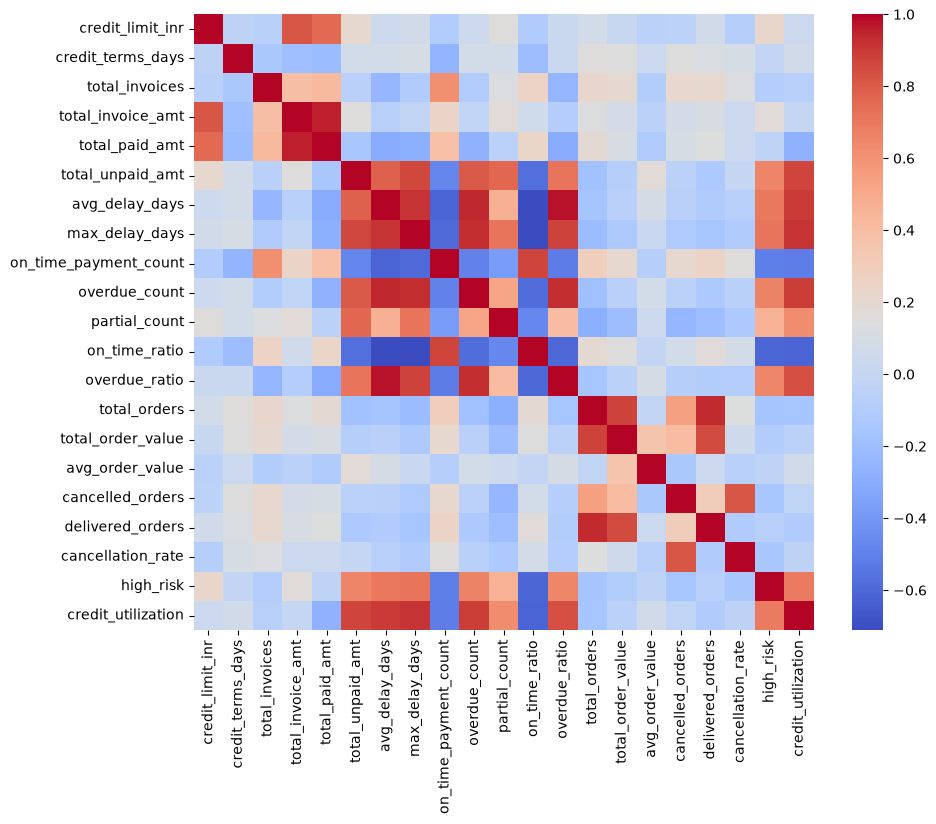

high_risk                1.000000
max_delay_days           0.717422
avg_delay_days           0.704430
credit_utilization       0.687735
overdue_count            0.664359
total_unpaid_amt         0.656170
overdue_ratio            0.647477
partial_count            0.464302
credit_limit_inr         0.221646
total_invoice_amt        0.164546
credit_terms_days       -0.008047
avg_order_value         -0.032653
total_paid_amt          -0.034256
delivered_orders        -0.071101
total_invoices          -0.087121
total_order_value       -0.090091
cancellation_rate       -0.149800
cancelled_orders        -0.151456
total_orders            -0.162335
on_time_payment_count   -0.506864
on_time_ratio           -0.608664
Name: high_risk, dtype: float64

In [42]:
plt.figure(figsize=(10, 8))
corr = df_master.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f")
plt.show()

corr["high_risk"].sort_values(ascending=False)

Checking high risk correlation column with every other column to see any data leakage

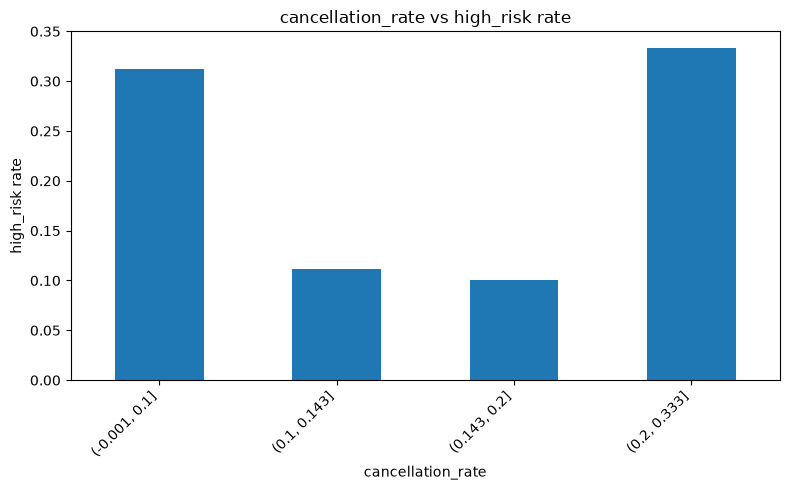

In [43]:
def plot_binned_risk(df, col, bins=6, title=None):
    binned = pd.qcut(df[col], q=bins, duplicates="drop")
    risk_by_bin = df.groupby(binned, observed=True)["high_risk"].mean()

    plt.figure(figsize=(8, 5))
    risk_by_bin.plot(kind="bar")
    plt.title(title or f"{col} vs high_risk rate")
    plt.xlabel(col)
    plt.ylabel("high_risk rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_binned_risk(df_master, "cancellation_rate", title="cancellation_rate vs high_risk rate")

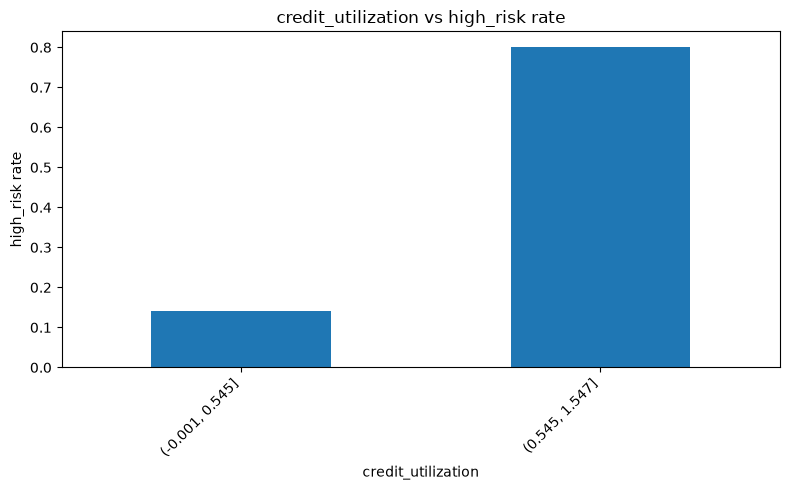

In [44]:
plot_binned_risk(df_master, "credit_utilization", title="credit_utilization vs high_risk rate")

In [45]:
df_master.sample(10)

,distributor_id,distributor_name,region,city,channel,credit_limit_inr,credit_terms_days,onboarded_date,total_invoices,total_invoice_amt,total_paid_amt,total_unpaid_amt,avg_delay_days,max_delay_days,on_time_payment_count,overdue_count,partial_count,on_time_ratio,overdue_ratio,total_orders,total_order_value,avg_order_value,cancelled_orders,delivered_orders,latest_order_date,cancellation_rate,high_risk,credit_utilization
20,DIST-036,Prime Distributors,North,Delhi,general_trade,100000,45,2022-06-28,7.0,152636.0,152636.0,0.0,-1.571429,0.0,7.0,0.0,0.0,1.000000,0.000000,8.0,900000.0,112500.000000,2.0,6.0,2025-08-24,0.250000,0,0.000000
44,DIST-080,Jai Distributors,West,Ahmedabad,institution,1000000,21,2023-09-27,4.0,895220.0,895220.0,0.0,9.250000,23.0,2.0,0.0,0.0,0.500000,0.000000,5.0,875000.0,175000.000000,0.0,5.0,2025-07-30,0.000000,0,0.000000
28,DIST-049,Ravi Traders,West,Pune,modern_trade,100000,45,2022-07-21,9.0,196062.0,196062.0,0.0,-1.777778,0.0,9.0,0.0,0.0,1.000000,0.000000,16.0,2900000.0,181250.000000,2.0,12.0,2025-09-04,0.125000,0,0.000000
1,DIST-003,Jai Brothers,North,Delhi,modern_trade,200000,15,2024-02-24,11.0,506292.0,506292.0,0.0,-1.636364,0.0,11.0,0.0,0.0,1.000000,0.000000,10.0,1650000.0,165000.000000,2.0,7.0,2025-09-28,0.200000,0,0.000000
49,DIST-088,New Enterprises,North,Chandigarh,modern_trade,500000,30,2025-04-20,7.0,676511.0,312730.0,363781.0,173.571429,439.0,2.0,3.0,1.0,0.285714,0.428571,6.0,850000.0,141666.666667,0.0,6.0,2025-07-09,0.000000,1,0.727562
16,DIST-027,Jai Traders,East,Kolkata,institution,750000,21,2024-04-20,6.0,1112124.0,1112124.0,0.0,-1.500000,0.0,6.0,0.0,0.0,1.000000,0.000000,16.0,2250000.0,140625.000000,0.0,14.0,2025-09-29,0.000000,0,0.000000
21,DIST-039,Star Traders,North,Chandigarh,general_trade,750000,21,2021-04-27,9.0,1595413.0,1595413.0,0.0,-1.000000,0.0,9.0,0.0,0.0,1.000000,0.000000,11.0,1125000.0,102272.727273,2.0,7.0,2025-08-15,0.181818,0,0.000000
25,DIST-046,Star Distributors,West,Ahmedabad,institution,300000,15,2024-09-29,12.0,783112.0,783112.0,0.0,-1.833333,0.0,12.0,0.0,0.0,1.000000,0.000000,12.0,1425000.0,118750.000000,0.0,11.0,2025-09-17,0.000000,0,0.000000
34,DIST-060,New Agencies,East,Kolkata,modern_trade,750000,45,2022-12-09,5.0,899889.0,899889.0,0.0,14.800000,45.0,3.0,0.0,0.0,0.600000,0.000000,13.0,1875000.0,144230.769231,0.0,9.0,2025-09-07,0.000000,0,0.000000
31,DIST-055,Modern Brothers,West,Mumbai,modern_trade,1000000,30,2025-05-22,7.0,1380118.0,1380118.0,0.0,26.000000,37.0,1.0,0.0,0.0,0.142857,0.000000,9.0,1250000.0,138888.888889,0.0,9.0,2025-08-19,0.000000,1,0.000000


## Modeling

In [46]:
num_cols = [
    "credit_limit_inr", "credit_terms_days", "credit_utilization",
    "total_invoices", "avg_delay_days", "max_delay_days", "on_time_ratio", "overdue_ratio",
    "total_orders", "avg_order_value", "cancellation_rate",
]
cat_cols = ["region", "channel"]

X = df_master[num_cols + cat_cols]
y = df_master["high_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

### Using RF to get a baseline

In [47]:
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42, min_samples_split=14, min_samples_leaf=4, class_weight="balanced")
model = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", rf_classifier)])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['credit_limit_inr','credit_terms_days','credit_utilization',..., 'cancellation_rate','region','channel']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

In [48]:
y_probs = model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_probs))
print("Test PR-AUC:", average_precision_score(y_test, y_probs))

Test ROC-AUC: 0.9090909090909092
Test PR-AUC: 0.8303571428571428


In [49]:
y_tr_probs = model.predict_proba(X_train)[:, 1]

print("Train ROC-AUC:", roc_auc_score(y_train, y_tr_probs))
print("Train PR-AUC:", average_precision_score(y_train, y_tr_probs))

Train ROC-AUC: 0.9839572192513368
Train PR-AUC: 0.9543335452426362


## Testing multiple models with optuna tuning

In [50]:
RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def pipe(clf):
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    return cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="average_precision").mean()

def objective_lr(trial):
    c = trial.suggest_float("lr_c", 1e-3, 10.0, log=True)
    clf = LogisticRegression(
        C=c, solver="lbfgs", class_weight="balanced", max_iter=1000,
        random_state=RANDOM_STATE
    )
    return pipe(clf)

def objective_rf(trial):
    n_estimators = trial.suggest_int("rf_n_estimators", 50, 200, step=5)
    max_depth = trial.suggest_int("rf_max_depth", 3, 10)
    min_samples_split = trial.suggest_int("rf_min_samples_split", 2, 8)
    min_samples_leaf = trial.suggest_int("rf_min_samples_leaf", 2, 8)
    clf = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth, 
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced", random_state=RANDOM_STATE
    )
    return pipe(clf)

def objective_xgb(trial):
    lr = trial.suggest_float("xgb_lr", 0.01, 0.2, log=True)
    max_depth = trial.suggest_int("xgb_max_depth", 2, 6)
    scale_pos_weight = trial.suggest_float("xgb_scale_pos_weight", 1.0, 5.0)
    subsample = trial.suggest_float("xgb_subsample", 0.6, 1.0)
    clf = XGBClassifier(
        learning_rate=lr, max_depth=max_depth, scale_pos_weight=scale_pos_weight,
        subsample=subsample, random_state=RANDOM_STATE, eval_metric="logloss"
    )
    return pipe(clf)

N_TRIALS = 10

studies = {}
print("Running Logistic Regression...")
study_lr = optuna.create_study(direction="maximize")
study_lr.optimize(objective_lr, n_trials=N_TRIALS)
studies['Logistic Regression'] = study_lr

print("Running Random Forest...")
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=N_TRIALS)
studies['Random Forest'] = study_rf

print("Running XGBoost...")
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)
studies['XGBoost'] = study_xgb

[I 2026-08-29 22:05:56,765] A new study created in memory with name: no-name-d687e1a9-66bd-429b-8faf-db7aee5e2ce8
[I 2026-08-29 22:05:56,796] Trial 0 finished with value: 0.8277777777777777 and parameters: {'lr_c': 1.0634864607453565}. Best is trial 0 with value: 0.8277777777777777.
[I 2026-08-29 22:05:56,824] Trial 1 finished with value: 0.8277777777777777 and parameters: {'lr_c': 1.2266701850096668}. Best is trial 0 with value: 0.8277777777777777.
[I 2026-08-29 22:05:56,851] Trial 2 finished with value: 0.9111111111111111 and parameters: {'lr_c': 0.003931680951235326}. Best is trial 2 with value: 0.9111111111111111.
[I 2026-08-29 22:05:56,879] Trial 3 finished with value: 0.9111111111111111 and parameters: {'lr_c': 0.004759159602882625}. Best is trial 2 with value: 0.9111111111111111.
[I 2026-08-29 22:05:56,907] Trial 4 finished with value: 0.8277777777777777 and parameters: {'lr_c': 0.20577004073542265}. Best is trial 2 with value: 0.9111111111111111.
[I 2026-08-29 22:05:56,934] Tri

Running Logistic Regression...


[I 2026-08-29 22:05:56,989] Trial 7 finished with value: 0.8777777777777777 and parameters: {'lr_c': 0.10784914598828012}. Best is trial 2 with value: 0.9111111111111111.
[I 2026-08-29 22:05:57,017] Trial 8 finished with value: 0.8277777777777777 and parameters: {'lr_c': 6.583500576172139}. Best is trial 2 with value: 0.9111111111111111.
[I 2026-08-29 22:05:57,044] Trial 9 finished with value: 0.9111111111111111 and parameters: {'lr_c': 0.02775234574991667}. Best is trial 2 with value: 0.9111111111111111.
[I 2026-08-29 22:05:57,045] A new study created in memory with name: no-name-4becf312-5ec3-41f3-8533-5d404b71753e


Running Random Forest...


[I 2026-08-29 22:05:57,424] Trial 0 finished with value: 0.751111111111111 and parameters: {'rf_n_estimators': 200, 'rf_max_depth': 10, 'rf_min_samples_split': 3, 'rf_min_samples_leaf': 3}. Best is trial 0 with value: 0.751111111111111.
[I 2026-08-29 22:05:57,617] Trial 1 finished with value: 0.751111111111111 and parameters: {'rf_n_estimators': 95, 'rf_max_depth': 9, 'rf_min_samples_split': 7, 'rf_min_samples_leaf': 4}. Best is trial 0 with value: 0.751111111111111.
[I 2026-08-29 22:05:57,982] Trial 2 finished with value: 0.8011111111111109 and parameters: {'rf_n_estimators': 195, 'rf_max_depth': 3, 'rf_min_samples_split': 6, 'rf_min_samples_leaf': 6}. Best is trial 2 with value: 0.8011111111111109.
[I 2026-08-29 22:05:58,269] Trial 3 finished with value: 0.8844444444444444 and parameters: {'rf_n_estimators': 150, 'rf_max_depth': 7, 'rf_min_samples_split': 6, 'rf_min_samples_leaf': 7}. Best is trial 3 with value: 0.8844444444444444.
[I 2026-08-29 22:05:58,477] Trial 4 finished with va

Running XGBoost...


[I 2026-08-29 22:05:59,827] Trial 0 finished with value: 0.823015873015873 and parameters: {'xgb_lr': 0.09070929601704832, 'xgb_max_depth': 2, 'xgb_scale_pos_weight': 2.5461132742019736, 'xgb_subsample': 0.6964077674332435}. Best is trial 0 with value: 0.823015873015873.
[I 2026-08-29 22:06:00,102] Trial 1 finished with value: 0.7396825396825395 and parameters: {'xgb_lr': 0.06966582457299789, 'xgb_max_depth': 4, 'xgb_scale_pos_weight': 3.609311407588725, 'xgb_subsample': 0.648249169758539}. Best is trial 0 with value: 0.823015873015873.
[I 2026-08-29 22:06:00,394] Trial 2 finished with value: 0.7396825396825395 and parameters: {'xgb_lr': 0.07008348062839578, 'xgb_max_depth': 4, 'xgb_scale_pos_weight': 2.8394472915663647, 'xgb_subsample': 0.7830640520991129}. Best is trial 0 with value: 0.823015873015873.
[I 2026-08-29 22:06:00,737] Trial 3 finished with value: 0.7694444444444443 and parameters: {'xgb_lr': 0.03773714697132969, 'xgb_max_depth': 4, 'xgb_scale_pos_weight': 2.07741769651938

In [51]:
opt_clf_lr = LogisticRegression(
    C=study_lr.best_params["lr_c"],
    class_weight="balanced", solver="lbfgs", max_iter=1000, random_state=RANDOM_STATE
)

opt_clf_rf = RandomForestClassifier(
    n_estimators=study_rf.best_params["rf_n_estimators"],
    max_depth=study_rf.best_params["rf_max_depth"],
    min_samples_split=study_rf.best_params["rf_min_samples_split"],
    class_weight="balanced", random_state=RANDOM_STATE
)

opt_clf_xgb = XGBClassifier(
    learning_rate=study_xgb.best_params["xgb_lr"],
    max_depth=study_xgb.best_params["xgb_max_depth"],
    scale_pos_weight=study_xgb.best_params["xgb_scale_pos_weight"],
    subsample=study_xgb.best_params["xgb_subsample"],
    random_state=RANDOM_STATE, eval_metric="logloss"
)

models = {
    'Logistic Regression': Pipeline([("preprocessor", preprocessor), ("classifier", opt_clf_lr)]),
    'Random Forest': Pipeline([("preprocessor", preprocessor), ("classifier", opt_clf_rf)]),
    'XGBoost': Pipeline([("preprocessor", preprocessor), ("classifier", opt_clf_xgb)])
}

results = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    test_probs = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "CV PR-AUC": studies[name].best_value,
        "Test PR-AUC": average_precision_score(y_test, test_probs),
        "Test ROC-AUC": roc_auc_score(y_test, test_probs),
    })

results_df = pd.DataFrame(results).sort_values(by="Test ROC-AUC", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_pipeline = models[best_model_name]

,Model,CV PR-AUC,Test PR-AUC,Test ROC-AUC
0,Logistic Regression,0.911111,0.830357,0.909091
1,Random Forest,0.884444,0.622024,0.863636
2,XGBoost,0.823016,0.542857,0.818182


### Selecting a desision thresold

In [52]:
probas = cross_val_predict(
    best_pipeline, X_train, y_train, cv=cv, method="predict_proba"
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, probas)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
thresholds

array([0.4213158 , 0.42219327, 0.42479253, 0.42528363, 0.4280061 ,
       0.42991042, 0.43042394, 0.43223292, 0.43335061, 0.43712832,
       0.43767109, 0.43769907, 0.43808259, 0.43844343, 0.43887127,
       0.4402977 , 0.44044879, 0.4407633 , 0.44203961, 0.44243557,
       0.44592592, 0.4514465 , 0.45172463, 0.45270722, 0.45509299,
       0.4560468 , 0.45639363, 0.45898525, 0.46161312, 0.46346434,
       0.46526679, 0.46815977, 0.46933706, 0.47275472, 0.47743027,
       0.52890551, 0.54943444, 0.54963184, 0.57001473, 0.57800501,
       0.57921056, 0.58486559, 0.59164468, 0.60458909, 0.62285636])

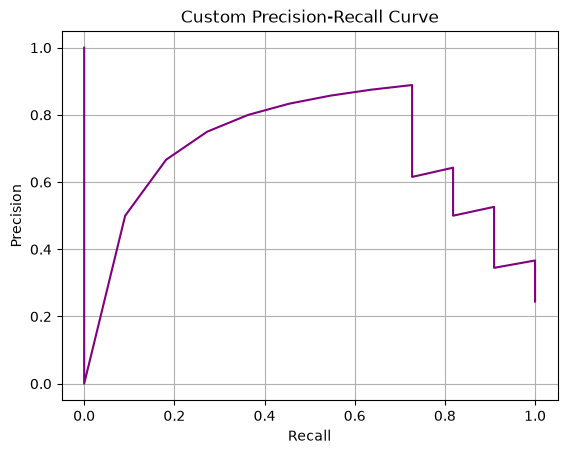

In [53]:
plt.plot(recalls, precisions, label=f'Logistic Regression', color='purple')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Custom Precision-Recall Curve')
plt.grid(True)
plt.show()

In [54]:
best_idx = f1_scores[:-1].argmax()

In [55]:
THRESHOLD = thresholds[best_idx]

print(f"best threshold from PR curve: {THRESHOLD}")
print(f"precision: {precisions[best_idx]}")
print(f"recall: {recalls[best_idx]}")
print(f"F1: {f1_scores[best_idx]}")

best threshold from PR curve: 0.54943443856018
precision: 0.8888888888888888
recall: 0.7272727272727273
F1: 0.7999999995049999


In [56]:
best_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['credit_limit_inr','credit_terms_days','credit_utilization',..., 'cancellation_rate','region','channel']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

In [57]:
test_probs = best_pipeline.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= THRESHOLD).astype(int)

print(f"model: {best_model_name}")
print(f"Classification Report threshold={THRESHOLD}")
print(classification_report(y_test, test_preds))
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_preds))

model: Logistic Regression
Classification Report threshold=0.54943443856018
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        11
           1       1.00      0.50      0.67         4

    accuracy                           0.87        15
   macro avg       0.92      0.75      0.79        15
weighted avg       0.89      0.87      0.85        15

Confusion Matrix:
[[11  0]
 [ 2  2]]


In [58]:
train_probs = best_pipeline.predict_proba(X_train)[:, 1]
train_preds = (train_probs >= THRESHOLD).astype(int)

print(f"Classification Report threshold={THRESHOLD}")
print(classification_report(y_train, train_preds))
print("Confusion Matrix:")
print(confusion_matrix(y_train, train_preds))

Classification Report threshold=0.54943443856018
              precision    recall  f1-score   support

           0       0.92      0.97      0.94        34
           1       0.89      0.73      0.80        11

    accuracy                           0.91        45
   macro avg       0.90      0.85      0.87        45
weighted avg       0.91      0.91      0.91        45

Confusion Matrix:
[[33  1]
 [ 3  8]]


### Feature importance (also doubles as a leakage sanity check)

If one or two features dominate near-100% of the importance, that's still worth a second look even
after fixing the time-based split.

In [59]:
fitted_clf = best_pipeline.named_steps["classifier"]
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
display(fitted_clf)
display(feature_names)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.003931680951235326
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization 

array(['num__credit_limit_inr', 'num__credit_terms_days',
       'num__credit_utilization', 'num__total_invoices',
       'num__avg_delay_days', 'num__max_delay_days', 'num__on_time_ratio',
       'num__overdue_ratio', 'num__total_orders', 'num__avg_order_value',
       'num__cancellation_rate', 'cat__region_East', 'cat__region_North',
       'cat__region_South', 'cat__region_West',
       'cat__channel_general_trade', 'cat__channel_institution',
       'cat__channel_modern_trade'], dtype=object)

In [60]:
# fitted_clf.feature_importances_
fitted_clf.coef_

array([[ 0.02320982,  0.01172278,  0.05917112,  0.00454025,  0.05598638,
         0.06013241, -0.05291961,  0.04842009, -0.02231027,  0.0007229 ,
        -0.00762653,  0.00279517, -0.00389074, -0.00674918,  0.00784493,
        -0.00550995, -0.00448169,  0.00999182]])

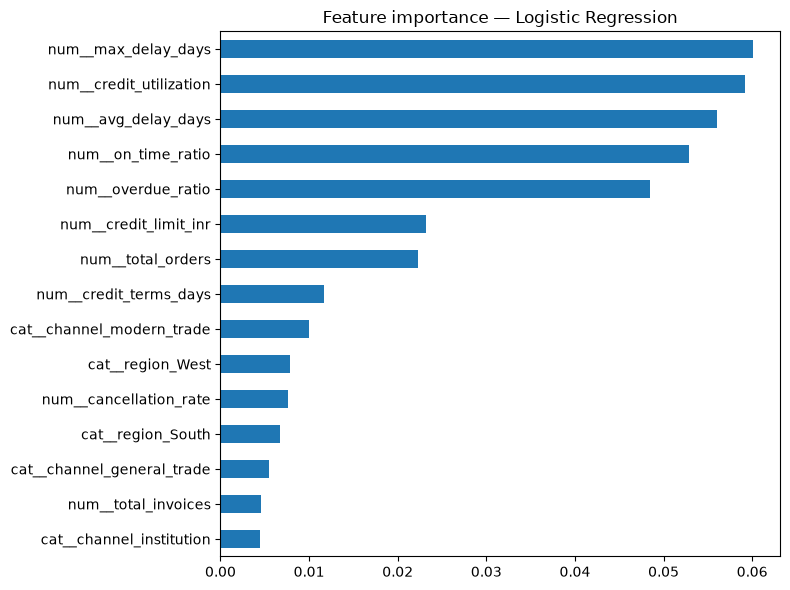

In [61]:
importances = pd.Series(np.abs(fitted_clf.coef_[0]), index=feature_names)

importances.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(8, 6))
plt.title(f"Feature importance — {best_model_name}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [66]:
fitted_clf.get_params

<bound method BaseEstimator.get_params of LogisticRegression(C=0.003931680951235326, class_weight='balanced',
                   max_iter=1000, random_state=42)>

Getting data for api tetsting:

In [67]:
df_master.head()

,distributor_id,distributor_name,region,city,channel,credit_limit_inr,credit_terms_days,onboarded_date,total_invoices,total_invoice_amt,total_paid_amt,total_unpaid_amt,avg_delay_days,max_delay_days,on_time_payment_count,overdue_count,partial_count,on_time_ratio,overdue_ratio,total_orders,total_order_value,avg_order_value,cancelled_orders,delivered_orders,latest_order_date,cancellation_rate,high_risk,credit_utilization
0,DIST-002,Modern Traders,North,Chandigarh,institution,750000,15,2024-04-24,10.0,1790589.0,1790589.0,0.0,-1.000000,0.0,10.0,0.0,0.0,1.0,0.0,4.0,625000.0,156250.000000,1.0,2.0,2025-09-11,0.2500,0,0.0
1,DIST-003,Jai Brothers,North,Delhi,modern_trade,200000,15,2024-02-24,11.0,506292.0,506292.0,0.0,-1.636364,0.0,11.0,0.0,0.0,1.0,0.0,10.0,1650000.0,165000.000000,2.0,7.0,2025-09-28,0.2000,0,0.0
2,DIST-004,Om Brothers,West,Mumbai,general_trade,750000,30,2021-01-14,9.0,1399559.0,1399559.0,0.0,-1.777778,0.0,9.0,0.0,0.0,1.0,0.0,11.0,1600000.0,145454.545455,0.0,11.0,2025-09-24,0.0000,0,0.0
3,DIST-008,Jai Distributors,East,Patna,modern_trade,1000000,15,2021-04-04,13.0,3199465.0,3199465.0,0.0,-1.846154,0.0,13.0,0.0,0.0,1.0,0.0,16.0,2125000.0,132812.500000,3.0,11.0,2025-09-09,0.1875,0,0.0
4,DIST-009,New Enterprises,North,Delhi,modern_trade,500000,30,2023-07-18,8.0,985994.0,985994.0,0.0,-1.500000,0.0,8.0,0.0,0.0,1.0,0.0,9.0,1375000.0,152777.777778,0.0,8.0,2025-08-06,0.0000,0,0.0


In [71]:
TEST_DIST_ID = "DIST-004"

In [72]:
dist = df_master[df_master["distributor_id"] == TEST_DIST_ID][[
"distributor_id",
"distributor_name",
"region",
"city",
"channel",
"credit_limit_inr",
"credit_terms_days",
]].copy()

date_cols = []
for col in date_cols:
    dist[col] = pd.to_datetime(dist[col]).dt.strftime('%Y-%m-%d')

json_output = dist.to_json(orient='records')
print(json_output)


[{"distributor_id":"DIST-004","distributor_name":"Om Brothers","region":"West","city":"Mumbai","channel":"general_trade","credit_limit_inr":750000,"credit_terms_days":30}]


In [74]:
dist_orders = df_orders[df_orders["distributor_id"] == TEST_DIST_ID][[
    "order_id",
"order_date",
"order_value_inr",
"order_status"
]].copy()

date_cols = ["order_date"]
for col in date_cols:
    dist_orders[col] = pd.to_datetime(dist_orders[col]).dt.strftime('%Y-%m-%d')

json_output = dist_orders.to_json(orient='records')
print(json_output)


[{"order_id":"ORD-00047","order_date":"2024-09-11","order_value_inr":100000.0,"order_status":"delivered"},{"order_id":"ORD-00048","order_date":"2024-06-16","order_value_inr":100000.0,"order_status":"delivered"},{"order_id":"ORD-00049","order_date":"2026-04-02","order_value_inr":25000.0,"order_status":"pending"},{"order_id":"ORD-00050","order_date":"2025-09-24","order_value_inr":75000.0,"order_status":"delivered"},{"order_id":"ORD-00051","order_date":"2025-05-13","order_value_inr":100000.0,"order_status":"delivered"},{"order_id":"ORD-00052","order_date":"2026-03-28","order_value_inr":75000.0,"order_status":"delivered"},{"order_id":"ORD-00053","order_date":"2026-04-22","order_value_inr":100000.0,"order_status":"cancelled"},{"order_id":"ORD-00054","order_date":"2025-04-21","order_value_inr":300000.0,"order_status":"delivered"},{"order_id":"ORD-00055","order_date":"2025-10-13","order_value_inr":25000.0,"order_status":"cancelled"},{"order_id":"ORD-00056","order_date":"2026-02-23","order_val

In [73]:
dist_payments = df_payments[df_payments["distributor_id"] == TEST_DIST_ID][[
    "payment_id", "invoice_id", "invoice_date", "invoice_amount_inr",
    "due_date", "payment_date", "amount_paid_inr", "payment_status"
]].copy()

date_cols = ["invoice_date", "due_date", "payment_date"]
for col in date_cols:
    dist_payments[col] = pd.to_datetime(dist_payments[col]).dt.strftime('%Y-%m-%d')

json_output = dist_payments.to_json(orient='records')
print(json_output)


[{"payment_id":"PAY-000043","invoice_id":"INV-000043","invoice_date":"2025-07-05","invoice_amount_inr":149259,"due_date":"2025-08-04","payment_date":"2025-08-04","amount_paid_inr":149259,"payment_status":"paid"},{"payment_id":"PAY-000039","invoice_id":"INV-000039","invoice_date":"2025-02-24","invoice_amount_inr":195115,"due_date":"2025-03-26","payment_date":"2025-03-24","amount_paid_inr":195115,"payment_status":"paid"},{"payment_id":"PAY-000044","invoice_id":"INV-000044","invoice_date":"2025-07-30","invoice_amount_inr":111377,"due_date":"2025-08-29","payment_date":"2025-08-27","amount_paid_inr":111377,"payment_status":"paid"},{"payment_id":"PAY-000042","invoice_id":"INV-000042","invoice_date":"2025-06-05","invoice_amount_inr":76149,"due_date":"2025-07-05","payment_date":"2025-07-03","amount_paid_inr":76149,"payment_status":"paid"},{"payment_id":"PAY-000046","invoice_id":"INV-000046","invoice_date":"2025-10-24","invoice_amount_inr":81667,"due_date":"2025-11-23","payment_date":"2025-11-2